# Predicción de Aprobación de Crédito con MLP

---

**Autor:** Borja Mora Méndez  
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)  
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)  
**Categoría:** Machine Learning · Supervisado · Clasificación · Redes Neuronales

---

### Objetivo

Entrenar un **Perceptrón Multicapa (MLP)** para predecir si una solicitud de microcrédito será **aprobada (1)** o **rechazada (0)** a partir de variables financieras y de comportamiento.

### Contexto de negocio

Una Fintech quiere automatizar parte de su proceso de evaluación de crédito. El reto es identificar buenos perfiles incluso cuando los ingresos no son suficientes por sí solos, combinando ingresos, comportamiento y nivel de endeudamiento.

## 1. Setup: librerías y configuración visual

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve
)

# Estilo visual -- sistema de color validado (consejo UX/UI Data)
BACKGROUND    = '#fbfbfb'
PURPLE        = '#7a7bff'
PURPLE_LIGHT  = '#9b9cff'
POSITIVE      = '#6b8158'
NEGATIVE      = '#c34031'
NEUTRAL_BAR   = '#d9d9d9'
NEUTRAL_LINE  = '#8f8c9e'
CONTEXT_LINES = [NEUTRAL_LINE, '#a89a8a', '#7d94a8']
INK           = '#111111'
MUTED         = '#707070'

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

pd.set_option('display.max_columns', None)

## 2. Carga de datos


In [2]:
# Carga del dataset
df = pd.read_excel("dataset_fintech.xlsx")

print(f"Registros: {df.shape[0]:,} | Variables: {df.shape[1]}")
df.head()

Registros: 120 | Variables: 5


,ID,Ingresos_Mensuales,Score_Comportamiento,Deudas_Activas,Aprobado
0,1,3018.73,80.70,0,1
1,2,2389.37,72.06,1,1
2,3,3018.15,91.56,1,1
3,4,3718.43,45.41,0,1
4,5,2312.44,11.60,1,0


## 3. EDA: Análisis exploratorio de datos

In [3]:
df.describe().round(2)

,ID,Ingresos_Mensuales,Score_Comportamiento,Deudas_Activas,Aprobado
count,120.00,120.00,120.00,120.00,120.00
mean,60.50,2394.57,53.85,0.88,0.43
std,34.79,890.25,25.85,0.83,0.50
min,1.00,400.00,10.04,0.00,0.00
25%,30.75,2018.56,31.98,0.00,0.00
50%,60.50,2279.10,52.98,1.00,0.00
75%,90.25,2660.32,76.88,1.00,1.00
max,120.00,9500.00,98.34,4.00,1.00


In [4]:
# Tipos de datos, nulos y valores únicos
info = pd.DataFrame({
    'Tipo': df.dtypes,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos': df.nunique()
})
info

,Tipo,Nulos,% Nulos,Únicos
ID,int64,0,0.0,120
Ingresos_Mensuales,float64,0,0.0,120
Score_Comportamiento,float64,0,0.0,119
Deudas_Activas,int64,0,0.0,5
Aprobado,int64,0,0.0,2


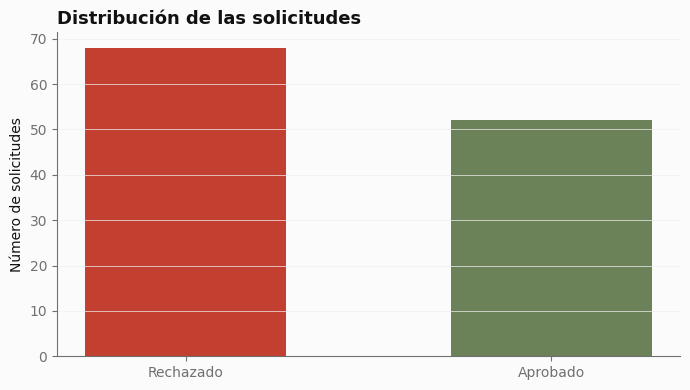

Rechazados: 68 (56.7%)
Aprobados:  52 (43.3%)


In [5]:
# Distribución del target
conteo = df['Aprobado'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    ['Rechazado', 'Aprobado'],
    conteo.values,
    width=0.55,
    color=[NEGATIVE, POSITIVE]
)

ax.set_title('Distribución de las solicitudes', loc='left')
ax.set_ylabel('Número de solicitudes')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

print(f"Rechazados: {conteo[0]} ({conteo[0]/len(df):.1%})")
print(f"Aprobados:  {conteo[1]} ({conteo[1]/len(df):.1%})")

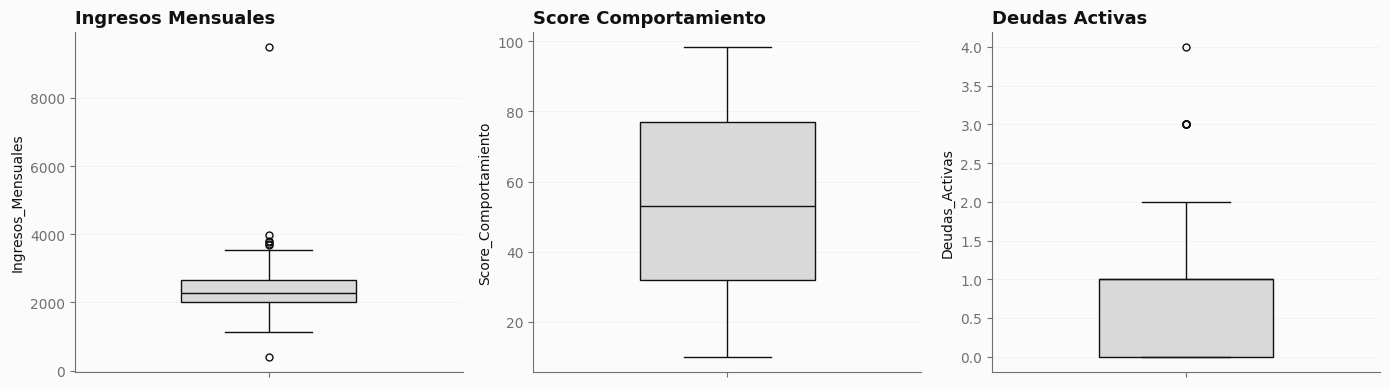

In [6]:
# Detección visual de valores extremos
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

variables = ['Ingresos_Mensuales', 'Score_Comportamiento', 'Deudas_Activas']
for ax, col in zip(axes, variables):
    sns.boxplot(
        data=df,
        y=col,
        ax=ax,
        color=NEUTRAL_BAR,
        width=0.45,
        fliersize=5,
        linecolor=INK
    )
    ax.set_title(col.replace('_', ' '), loc='left')
    ax.set_xlabel('')
    ax.grid(axis='y')

plt.tight_layout()
plt.show()

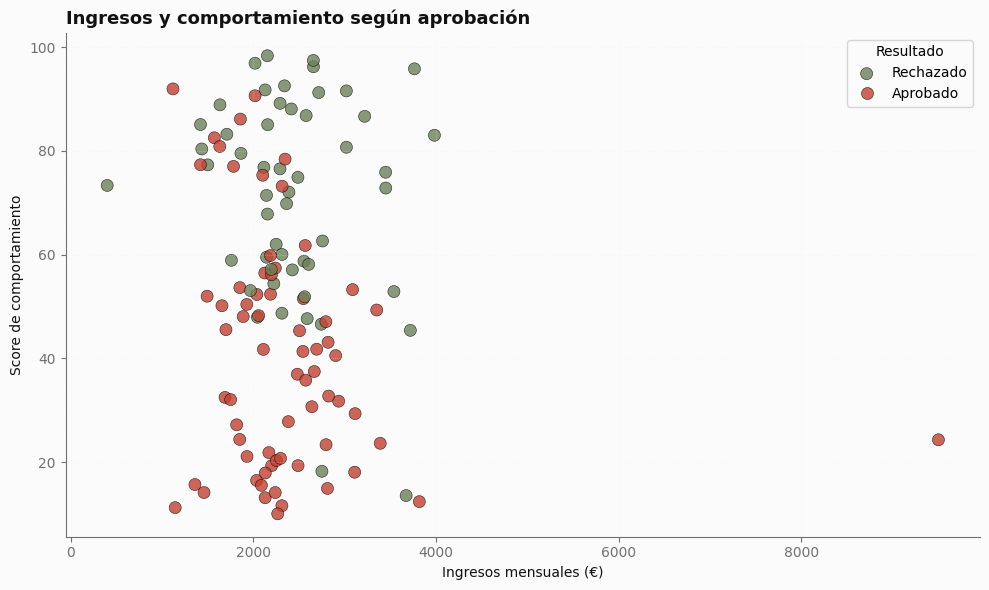

In [7]:
# Relación entre ingresos, comportamiento y aprobación
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Ingresos_Mensuales',
    y='Score_Comportamiento',
    hue='Aprobado',
    palette={0: NEGATIVE, 1: POSITIVE},
    s=75,
    edgecolor='black',
    linewidth=0.4,
    alpha=0.8,
    ax=ax
)

ax.set_title('Ingresos y comportamiento según aprobación', loc='left')
ax.set_xlabel('Ingresos mensuales (€)')
ax.set_ylabel('Score de comportamiento')
ax.grid(True, linestyle=':', alpha=0.5)
ax.legend(title='Resultado', labels=['Rechazado', 'Aprobado'])
plt.tight_layout()
plt.show()

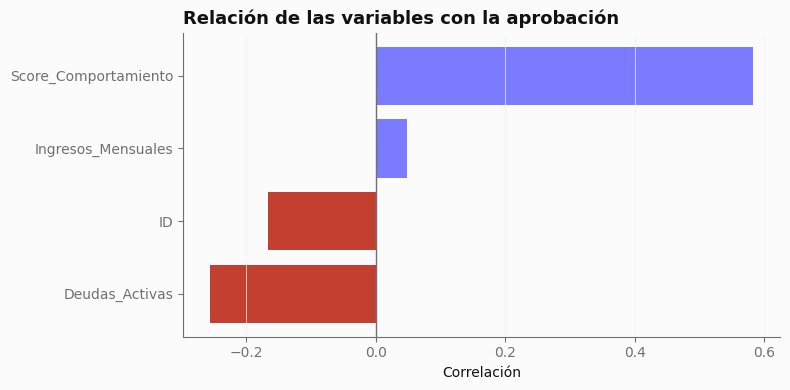

Score_Comportamiento    0.582
Ingresos_Mensuales      0.048
ID                     -0.166
Deudas_Activas         -0.256
Name: Aprobado, dtype: float64

In [8]:
# Correlaciones con la variable objetivo
correlaciones = (
    df.corr(numeric_only=True)['Aprobado']
    .drop('Aprobado')
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(
    correlaciones.index,
    correlaciones.values,
    color=[NEGATIVE if v < 0 else PURPLE for v in correlaciones.values]
)
ax.axvline(0, color=MUTED, linewidth=1)
ax.set_title('Relación de las variables con la aprobación', loc='left')
ax.set_xlabel('Correlación')
ax.grid(axis='x')
plt.tight_layout()
plt.show()

correlaciones.sort_values(ascending=False).round(3)

## Conclusiones del EDA

- El dataset contiene **120 solicitudes** y no presenta valores nulos.
- La variable objetivo está razonablemente equilibrada: **56,7% rechazadas y 43,3% aprobadas**.
- Los ingresos presentan algunos valores extremos que pueden afectar a una red neuronal si no se escalan correctamente.
- La aprobación no parece depender de una única variable: el **score de comportamiento**, los ingresos y las deudas aportan señales complementarias.
- La relación entre variables y target no parece completamente lineal, por lo que un modelo capaz de aprender relaciones no lineales resulta adecuado.

## 4. Preparación de los datos

In [9]:
X = df[['Ingresos_Mensuales', 'Score_Comportamiento', 'Deudas_Activas']]
y = df['Aprobado']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 96 | Test: 24


In [10]:
# Las redes neuronales son sensibles a la escala de las variables.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Construcción del modelo MLP

In [11]:
mlp = MLPClassifier(
    hidden_layer_sizes=(8, 4),
    max_iter=1000,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)

print(mlp)

MLPClassifier(hidden_layer_sizes=(8, 4), max_iter=1000, random_state=42)


In [12]:
# Predicciones y probabilidades

y_pred = mlp.predict(X_test_scaled)
y_scores = mlp.predict_proba(X_test_scaled)[:, 1]

## 6. Evaluación del modelo

In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_scores)

resultados = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1', 'AUC-ROC'],
    'Valor': [accuracy, precision, recall, f1, auc_roc]
})

resultados['Valor'] = resultados['Valor'].round(3)
resultados

,Métrica,Valor
0,Accuracy,0.875
1,Precision,0.889
2,Recall,0.800
3,F1,0.842
4,AUC-ROC,0.871


In [14]:
print(classification_report(
    y_test,
    y_pred,
    target_names=['Rechazado', 'Aprobado']
))

              precision    recall  f1-score   support

   Rechazado       0.87      0.93      0.90        14
    Aprobado       0.89      0.80      0.84        10

    accuracy                           0.88        24
   macro avg       0.88      0.86      0.87        24
weighted avg       0.88      0.88      0.87        24



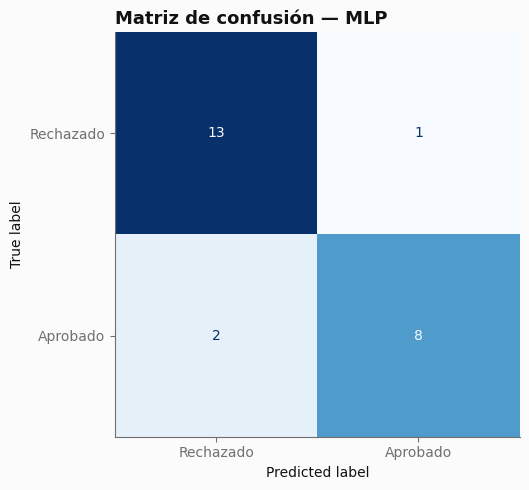

In [16]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Rechazado', 'Aprobado']
)

disp.plot(
    cmap=plt.cm.Blues,
    values_format='d',
    colorbar=False
)

plt.title('Matriz de confusión — MLP', loc='left')
plt.grid(False)
plt.tight_layout()
plt.show()

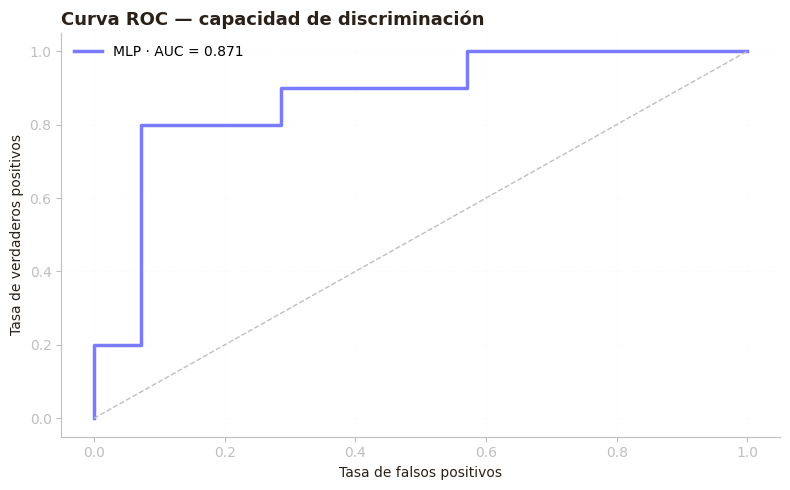

In [ ]:
# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_scores)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    fpr,
    tpr,
    color=PURPLE,
    linewidth=2.5,
    label=f'MLP · AUC = {auc_roc:.3f}'
)
ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color=INK,
    linewidth=1
)

ax.set_title('Curva ROC — capacidad de discriminación', loc='left')
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.legend(frameon=False)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### Interpretación de las métricas

- **Accuracy = 87,5%**: el modelo clasifica correctamente aproximadamente **9 de cada 10 solicitudes**.
- **Recall = 80,0% en aprobados**: identifica 8 de cada 10 solicitudes que realmente pertenecen a la clase aprobada.
- **F1 = 84,2%**: mantiene un buen equilibrio entre precisión y capacidad de detección de aprobados.
- **AUC-ROC = 0,871**: el modelo presenta una buena capacidad para separar solicitudes aprobadas y rechazadas.

## 7. Modelo alternativo — Regresión Logística

Para saber si la complejidad del MLP aporta valor real, se compara con un modelo mucho más
simple e interpretable. En *credit scoring* esto no es un detalle académico: la Regresión
Logística sigue siendo el estándar regulatorio en muchas entidades precisamente porque sus
coeficientes se pueden explicar a un auditor, algo que un MLP no ofrece.

In [ ]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred_lr = logreg.predict(X_test_scaled)
y_scores_lr = logreg.predict_proba(X_test_scaled)[:, 1]

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_scores_lr)

comparacion_modelos = pd.DataFrame({
    'Modelo': ['MLP (8, 4)', 'Regresión Logística'],
    'Accuracy': [accuracy, accuracy_lr],
    'Precision': [precision, precision_lr],
    'Recall': [recall, recall_lr],
    'F1': [f1, f1_lr],
    'AUC-ROC': [auc_roc, auc_lr]
}).round(3)

comparacion_modelos

,Modelo,Accuracy,Precision,Recall,F1,AUC-ROC
0,"MLP (8, 4)",0.875,0.889,0.8,0.842,0.871
1,Regresión Logística,0.833,0.875,0.7,0.778,0.943


### Lectura de la comparativa

El MLP gana en accuracy, precision, recall y F1, pero la **Regresión Logística obtiene un
AUC-ROC notablemente superior (0,943 frente a 0,871)** — separa mejor las dos clases en todos
los umbrales posibles, no solo en el umbral de 0,5 que usan las métricas anteriores. Con
solo 120 registros y 3 variables, no hay evidencia suficiente de que el MLP aporte una
ventaja real sobre un modelo lineal: la diferencia observada es pequeña y perfectamente
podría invertirse con otra partición de los datos. Esto confirma la intuición del sector:
en *credit scoring* con pocas variables y relaciones razonablemente simples, el modelo
interpretable es, como mínimo, tan defendible como el más complejo.

## 8. Análisis de outliers

In [ ]:
# Comprobamos el impacto de los dos valores extremos más claros del dataset.
df_sin_outliers = df.drop([15, 82]).reset_index(drop=True)

print(f'Registros originales: {len(df)}')
print(f'Registros sin outliers: {len(df_sin_outliers)}')

Registros originales: 120
Registros sin outliers: 118


In [ ]:
X_sin = df_sin_outliers[['Ingresos_Mensuales', 'Score_Comportamiento', 'Deudas_Activas']]
y_sin = df_sin_outliers['Aprobado']

X_train_sin, X_test_sin, y_train_sin, y_test_sin = train_test_split(
    X_sin,
    y_sin,
    test_size=0.20,
    stratify=y_sin,
    random_state=42
)

scaler_sin = RobustScaler()
X_train_sin_scaled = scaler_sin.fit_transform(X_train_sin)
X_test_sin_scaled = scaler_sin.transform(X_test_sin)

mlp_sin = MLPClassifier(
    hidden_layer_sizes=(6, 8),
    max_iter=1000,
    random_state=42
)

mlp_sin.fit(X_train_sin_scaled, y_train_sin)

y_pred_sin = mlp_sin.predict(X_test_sin_scaled)
y_scores_sin = mlp_sin.predict_proba(X_test_sin_scaled)[:, 1]

accuracy_sin = accuracy_score(y_test_sin, y_pred_sin)
precision_sin = precision_score(y_test_sin, y_pred_sin)
recall_sin = recall_score(y_test_sin, y_pred_sin)
f1_sin = f1_score(y_test_sin, y_pred_sin)
auc_sin = roc_auc_score(y_test_sin, y_scores_sin)

In [ ]:
comparacion = pd.DataFrame({
    'Modelo': ['MLP original', 'MLP sin outliers'],
    'Accuracy': [accuracy, accuracy_sin],
    'Precision': [precision, precision_sin],
    'Recall': [recall, recall_sin],
    'F1': [f1, f1_sin],
    'AUC-ROC': [auc_roc, auc_sin]
}).round(3)

comparacion

,Modelo,Accuracy,Precision,Recall,F1,AUC-ROC
0,MLP original,0.875,0.889,0.8,0.842,0.871
1,MLP sin outliers,0.833,0.800,0.8,0.800,0.900


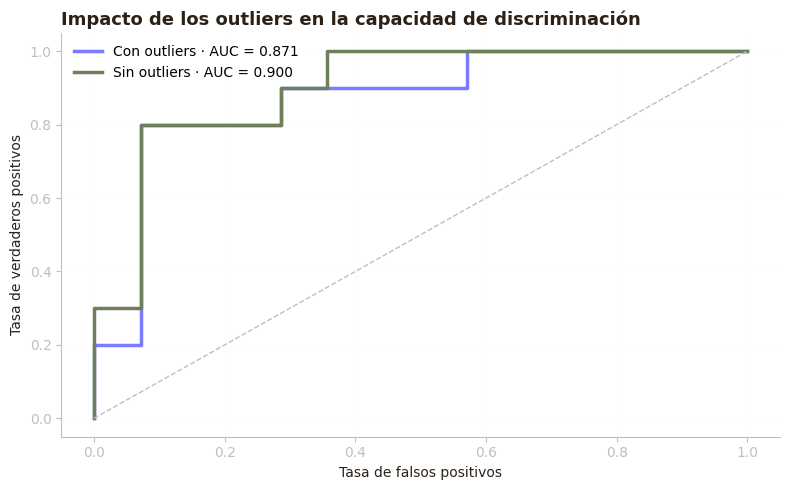

In [ ]:
# Comparación visual de las curvas ROC
fpr_con, tpr_con, _ = roc_curve(y_test, y_scores)
fpr_sin, tpr_sin, _ = roc_curve(y_test_sin, y_scores_sin)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    fpr_con,
    tpr_con,
    color=PURPLE,
    linewidth=2.5,
    label=f'Con outliers · AUC = {auc_roc:.3f}'
)
ax.plot(
    fpr_sin,
    tpr_sin,
    color=NEUTRAL_LINE,
    linewidth=2.5,
    label=f'Sin outliers · AUC = {auc_sin:.3f}'
)
ax.plot([0, 1], [0, 1], '--', color=INK, linewidth=1)

ax.set_title('Impacto de los outliers en la capacidad de discriminación', loc='left')
ax.set_xlabel('Tasa de falsos positivos')
ax.set_ylabel('Tasa de verdaderos positivos')
ax.legend(frameon=False)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## 9. Conclusión final

El **MLP con arquitectura (8, 4)** consigue un **87,5% de accuracy** y un **AUC-ROC de 0,871**, mostrando una buena capacidad para distinguir entre solicitudes aprobadas y rechazadas.

Comparado con una **Regresión Logística**, el MLP gana en accuracy y F1, pero la Regresión Logística obtiene un AUC-ROC superior (0,943). Con solo 120 registros y 3 variables, esta diferencia no es evidencia suficiente de que la complejidad del MLP aporte una ventaja real — y en un sector donde la interpretabilidad ante un auditor importa tanto como el rendimiento, esto refuerza la validez de seguir usando modelos lineales como estándar.

El análisis de outliers muestra un resultado interesante: al eliminarlos, el **AUC mejora hasta 0,900**, pero la accuracy baja al **83,3%**. Por tanto, no existe una mejora global suficiente como para afirmar que eliminar esos registros sea automáticamente mejor.

Desde el punto de vista de negocio, el modelo puede utilizarse como **herramienta de apoyo al scoring de crédito**, pero no debería sustituir por sí solo al sistema de decisión. En un entorno real sería necesario trabajar con más datos, validar el modelo sobre periodos posteriores y controlar especialmente los **falsos negativos**, ya que aprobar un cliente de riesgo puede tener un coste elevado para la entidad.